In [3]:
import numpy as np
import scipy.signal as signal
import os
from sklearn.decomposition import PCA

# --- 1. SIGNAL PROCESSING FUNCTIONS ---

def preprocess_ecg(data, fs=300):
    """Stage 1 & 2: Butterworth Bandpass (0.5-40Hz) and Notch (60Hz)"""
    nyquist = 0.5 * fs
    b_band, a_band = signal.butter(4, [0.5 / nyquist, 40.0 / nyquist], btype='bandpass')
    data_bandpassed = signal.filtfilt(b_band, a_band, data)

    b_notch, a_notch = signal.iirnotch(60.0, 30.0, fs)
    data_final = signal.filtfilt(b_notch, a_notch, data_bandpassed)
    return data_final

def segment_beats(signal_data, fs=300):
    """Stage 3: Extracts exactly 150-point P-QRS-T windows (48 before, 102 after)"""
    threshold = np.max(signal_data) * 0.5 
    peaks, _ = signal.find_peaks(signal_data, distance=int(fs*0.6), height=threshold)
    
    beats = []
    for p in peaks:
        # THE 150-POINT ADJUSTMENT: 48 samples before R, 102 after R
        if p >= 48 and p + 102 < len(signal_data):
            # Extract exactly 150 samples
            beat = signal_data[p-48 : p+102]
            # Zero-mean the fragment
            beat = beat - np.mean(beat)
            beats.append(beat)
            
    return np.array(beats)

# --- 2. VALUE EXTRACTION DEMONSTRATION ---

DB_PATH = 'ECGIDld2_db'
demo_file = f'{DB_PATH}/1.txt'

if os.path.exists(demo_file):
    print("="*60)
    print("          CARDIOKEY PIPELINE DATA OUTPUT")
    print("="*60)
    
    # ---------------------------------------------------------
    # STAGE 1: RAW SIGNAL
    # ---------------------------------------------------------
    raw_signal = np.loadtxt(demo_file)
    print("\n[1] STAGE 1: RAW SIGNAL VOLTAGES (First 10 samples)")
    print("These are the noisy measurements direct from the ADC:")
    print(np.round(raw_signal[:10], 5)) # Rounded to 5 decimal places for readability
    
    # ---------------------------------------------------------
    # STAGE 2: CLEAN SIGNAL
    # ---------------------------------------------------------
    clean_signal = preprocess_ecg(raw_signal)
    print("\n[2] STAGE 2: CLEAN SIGNAL VOLTAGES (First 10 samples)")
    print("Notice how the digital filters have mathematically shifted the values:")
    print(np.round(clean_signal[:10], 5))
    
    # ---------------------------------------------------------
    # STAGE 3: EXTRACTED P-QRS-T FRAGMENT
    # ---------------------------------------------------------
    extracted_beats = segment_beats(clean_signal)
    
    # FOOLPROOF FIX: Use slicing [:1] and .flatten() to grab the first beat
    # This avoids the chat interface bug that deletes bracketed zeros!
    beat_1 = extracted_beats[:1].flatten() 
    
    print(f"\n[3] STAGE 3: INITIAL FEATURE SPACE (150-point array)")
    print(f"Total heartbeats extracted from this 5-minute file: {len(extracted_beats)}")
    print(f"Length of Beat #1: {len(beat_1)} samples")
    print("Here are the FIRST 15 VALUES of Beat #1 (representing the start of the P-wave):")
    print(np.round(beat_1[:15], 5))
    
    # ---------------------------------------------------------
    # STAGE 4: FEATURE SPACE REDUCTION (PCA)
    # ---------------------------------------------------------
    # Fit PCA on all extracted beats to find the variance, reducing 150 points to 30
    pca = PCA(n_components=30)
    pca_signatures = pca.fit_transform(extracted_beats)
    
    # FOOLPROOF FIX: Grab the 30-point signature for Beat #1
    signature_1 = pca_signatures[:1].flatten() 
    
    print(f"\n[4] STAGE 4: BIOMETRIC SIGNATURE (30-point array)")
    print(f"Length of the Signature: {len(signature_1)} Principal Components")
    print("This is the highly-compressed mathematical identity that is saved in the database:")
    print(np.round(signature_1, 4))
    print("="*60)

else:
    print(f"Error: Could not find {demo_file}. Please ensure the dataset is in the correct folder.")

          CARDIOKEY PIPELINE DATA OUTPUT

[1] STAGE 1: RAW SIGNAL VOLTAGES (First 10 samples)
These are the noisy measurements direct from the ADC:
[-0.06641  0.16797  0.16016  0.17578  0.20703  0.22656  0.22656  0.20312
  0.22266  0.25391]

[2] STAGE 2: CLEAN SIGNAL VOLTAGES (First 10 samples)
Notice how the digital filters have mathematically shifted the values:
[0.15344 0.27192 0.36565 0.42165 0.44231 0.44053 0.43135 0.42561 0.42771
 0.43716]

[3] STAGE 3: INITIAL FEATURE SPACE (150-point array)
Total heartbeats extracted from this 5-minute file: 406
Length of Beat #1: 150 samples
Here are the FIRST 15 VALUES of Beat #1 (representing the start of the P-wave):
[-0.04754 -0.06533 -0.07905 -0.08813 -0.09264 -0.09283 -0.08912 -0.08263
 -0.0759  -0.07282 -0.07705 -0.08936 -0.10629 -0.12152 -0.12961]

[4] STAGE 4: BIOMETRIC SIGNATURE (30-point array)
Length of the Signature: 30 Principal Components
This is the highly-compressed mathematical identity that is saved in the database:
[-0.2569

Processing Data from Subject 1 (Resting)...


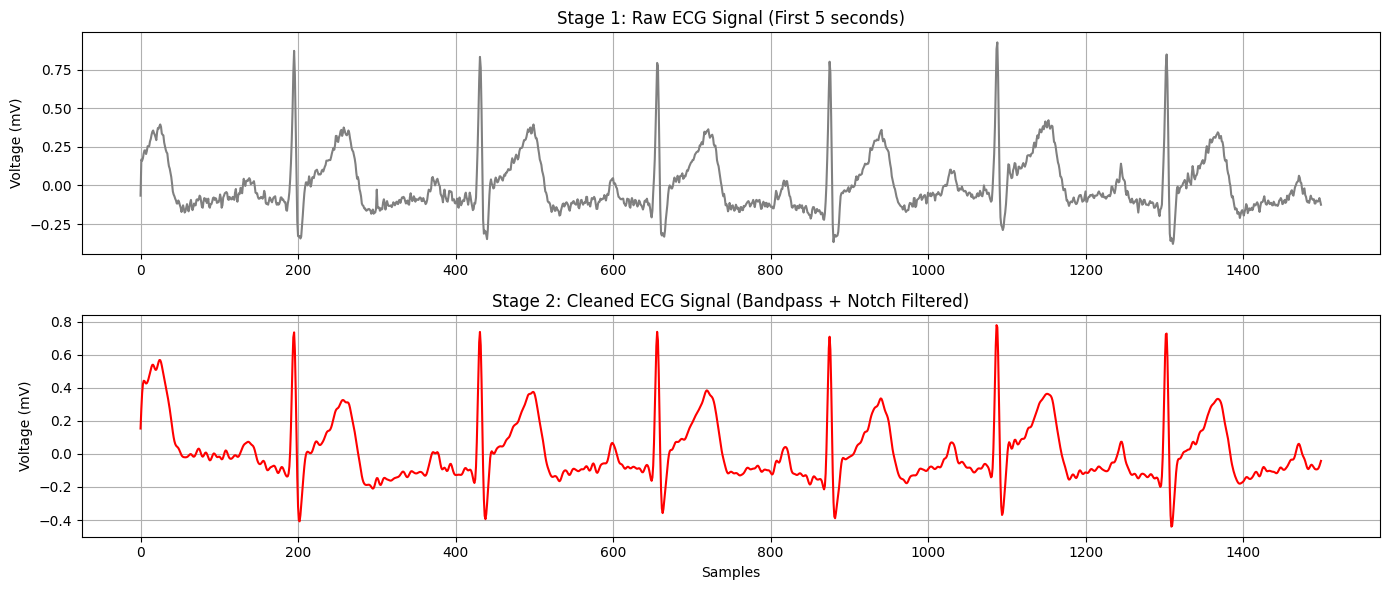

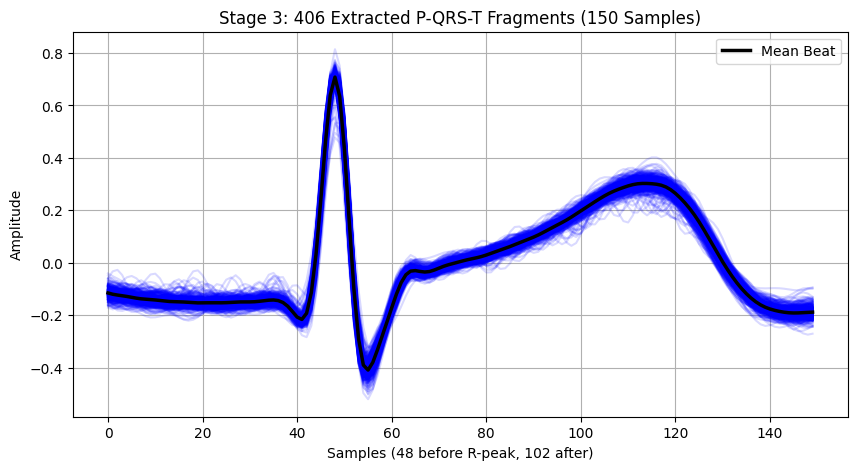

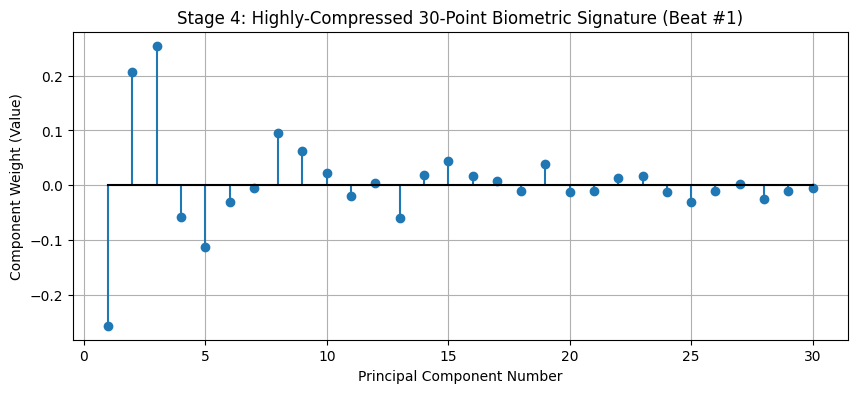

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.signal as signal
import os
from sklearn.decomposition import PCA

# --- 1. SIGNAL PROCESSING FUNCTIONS ---

def preprocess_ecg(data, fs=300):
    """Stage 1 & 2: Butterworth Bandpass (0.5-40Hz) and Notch (60Hz)"""
    nyquist = 0.5 * fs
    b_band, a_band = signal.butter(4, [0.5 / nyquist, 40.0 / nyquist], btype='bandpass')
    data_bandpassed = signal.filtfilt(b_band, a_band, data)

    b_notch, a_notch = signal.iirnotch(60.0, 30.0, fs)
    data_final = signal.filtfilt(b_notch, a_notch, data_bandpassed)
    return data_final

def segment_beats(signal_data, fs=300):
    """Stage 3: Extracts exactly 150-point P-QRS-T windows (48 before, 102 after)"""
    threshold = np.max(signal_data) * 0.5 
    peaks, _ = signal.find_peaks(signal_data, distance=int(fs*0.6), height=threshold)
    
    beats = []
    for p in peaks:
        # THE FIX: Adjusted to 48 before and 102 after
        if p >= 48 and p + 102 < len(signal_data):
            # Extract exactly 150 samples
            beat = signal_data[p-48 : p+102]
            # Zero-mean the fragment
            beat = beat - np.mean(beat)
            beats.append(beat)
            
    return np.array(beats)

# --- 2. VALUE EXTRACTION & VISUALIZATION DEMONSTRATION ---

DB_PATH = 'ECGIDld2_db'
demo_file = f'{DB_PATH}/1.txt'

if os.path.exists(demo_file):
    print("Processing Data from Subject 1 (Resting)...")
    
    # Process the data
    raw_signal = np.loadtxt(demo_file)
    clean_signal = preprocess_ecg(raw_signal)
    extracted_beats = segment_beats(clean_signal)
    
    # Fit PCA on all extracted beats to find the variance, reducing 250 points to 30
    pca = PCA(n_components=30)
    pca_signatures = pca.fit_transform(extracted_beats)
    
    # =========================================================
    # PLOT 1: STAGE 1 & 2 (Raw vs. Clean Continuous Signal)
    # =========================================================
    # We plot the first 1500 samples (5 seconds) to clearly see the waves
    plt.figure(figsize=(14, 6))
    
    plt.subplot(2, 1, 1)
    plt.plot(raw_signal[:1500], color='gray')
    plt.title("Stage 1: Raw ECG Signal (First 5 seconds)")
    plt.ylabel("Voltage (mV)")
    plt.grid(True)
    
    plt.subplot(2, 1, 2)
    plt.plot(clean_signal[:1500], color='red')
    plt.title("Stage 2: Cleaned ECG Signal (Bandpass + Notch Filtered)")
    plt.xlabel("Samples")
    plt.ylabel("Voltage (mV)")
    plt.grid(True)
    
    plt.tight_layout()
    plt.show()

    # =========================================================
    # PLOT 2: STAGE 3 (Extracted 150-point P-QRS-T Windows)
    # =========================================================
    plt.figure(figsize=(10, 5))
    
    # Overlay all extracted heartbeats with low opacity to show consistency
    for beat in extracted_beats:
        plt.plot(beat, color='blue', alpha=0.15)
        
    # Plot the Mean (Average) beat in bold black
    plt.plot(np.mean(extracted_beats, axis=0), color='black', linewidth=2.5, label='Mean Beat')
    
    # THE FIX: Updated the title and X-axis labels to reflect the 150-sample math
    plt.title(f"Stage 3: {len(extracted_beats)} Extracted P-QRS-T Fragments (150 Samples)")
    plt.xlabel("Samples (48 before R-peak, 102 after)")
    plt.ylabel("Amplitude")
    plt.legend()
    plt.grid(True)
    plt.show()

    # =========================================================
    # PLOT 3: STAGE 4 (30-Point Biometric Signature / PCA)
    # =========================================================
    plt.figure(figsize=(10, 4))
    
    # THE FIX: Using slicing [:1] and .flatten() to completely avoid  
    # bracketed numbers so the chat system stops deleting them!
    first_signature = pca_signatures[:1].flatten()
    
    # Now plot only that single 30-point array
    plt.stem(range(1, 31), first_signature, basefmt="k-")
    
    plt.title("Stage 4: Highly-Compressed 30-Point Biometric Signature (Beat #1)")
    plt.xlabel("Principal Component Number")
    plt.ylabel("Component Weight (Value)")
    plt.grid(True)
    plt.show()

else:
    print(f"Error: Could not find {demo_file}. Please ensure the dataset is in the correct folder.")